# Persona D EDA


## Structure of the notebook:
- Section 1: Data Loading and Profiling
- Section 2: Data Cleaning
- Section 3: Data Refinement for Business Questions
- Section 4: Team input

### Data Columns Used for analysis
- Use dt.day_name() and dt.month on metadata_originalPostingDate to find which posting days and months attract the most views and applications.
    * metadata_totalNumberOfView
    * metadata_totalNumberJobApplication
    * day of week on (metadata_originalPostingDate), 
    * month of year on (metadata_originalPostingDate)
    * <>

- Use str.contains to flag titles with keywords like Senior, Junior, Lead, Specialist, Manager. Compare median views and application counts across these groups.
proposed data column to analyze
    * metadata_totalNumberOfView
    * metadata_totalNumberJobApplication
    * <>

- Which primary_category has the lowest applications-per-vacancy ratio (least competitive)? Visualise as a horizontal bar chart.
proposed data column to analyze
    * <>


## Section 1 Source data loading and profiling


### Sanity Check

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv('data/SGJobData.csv')

# Sanity checks
print(df.shape)          # Expect (~1048585, 20)
print(df.dtypes)
print(df.head(3))


(1048585, 22)
categories                             object
employmentTypes                        object
metadata_expiryDate                    object
metadata_isPostedOnBehalf                bool
metadata_jobPostId                     object
metadata_newPostingDate                object
metadata_originalPostingDate           object
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
occupationId                          float64
positionLevels                         object
postedCompany_name                     object
salary_maximum                          int64
salary_minimum                          int64
salary_type                            object
status_id                               int64
status_jobStatus                       object
title                                  object
average_salary      

### Date columns need explicit parsing — do this early so date arithmetic works later:


In [34]:
df['metadata_originalPostingDate'] = pd.to_datetime(df['metadata_originalPostingDate'])
df['metadata_newPostingDate']       = pd.to_datetime(df['metadata_newPostingDate'])
df['metadata_expiryDate']           = pd.to_datetime(df['metadata_expiryDate'])


--- 

### Known data-quality landmines

Real datasets are dirty. Decide your handling and state it in your presentation.

- Salary outliers. salary_maximum goes up to $25,330,000/month. These are data-entry errors. Decide your cap (e.g. exclude rows where average_salary > 50_000, or clip at the 99th percentile using np.percentile).

- Recruitment agencies dominate. The top "companies" are agencies, not employers. If your question is "who is hiring?", agency-posted jobs distort the answer.

- Use metadata_isPostedOnBehalf and string filtering on postedCompany_name.
categories is a JSON string, not a list. A job can have 1–N categories. You will need str.extract, str.findall, or ast.literal_eval to parse it.

- Re-posts inflate row counts. A single role re-posted 5 times shows up as 5 rows. Use drop_duplicates(subset='metadata_jobPostId', keep='first') when counting unique roles.

- salary_minimum = 1 appears frequently — that is a placeholder, not a real salary. Filter it out with df[df['salary_minimum'] > 100].
Mixed nulls. Columns like positionLevels, employmentTypes, and salary_type contain None as a string, actual NaN, and legitimate blanks. Use .replace('None', np.nan) before .isnull() checks.

- Date coverage is uneven at the start and end of the range. Trim to whole months when computing trends.

---



### Initial Profiling

#### Shape, null count, basic stats and types

In [35]:
# initial profiling

# Shape, types, missing values at a glance
with pd.option_context('display.float_format', '{:,.2f}'.format):
    print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
    print("\nNull counts:\n", df.isnull().sum().sort_values(ascending=False).head(10))
    print("\nBasic stats:\n", df[['salary_minimum','salary_maximum','average_salary',
                                'minimumYearsExperience','numberOfVacancies']].describe())

Rows: 1,048,585  Columns: 22

Null counts:
 occupationId                    1048585
categories                         3988
metadata_expiryDate                3988
title                              3988
metadata_jobPostId                 3988
metadata_newPostingDate            3988
metadata_originalPostingDate       3988
status_jobStatus                   3988
salary_type                        3988
employmentTypes                    3988
dtype: int64

Basic stats:
        salary_minimum  salary_maximum  average_salary  minimumYearsExperience  \
count    1,048,585.00    1,048,585.00    1,048,585.00            1,048,585.00   
mean         3,815.31        5,723.58        4,769.45                    2.78   
std          3,172.18       50,183.87       25,478.09                    2.54   
min              0.00            0.00            0.00                    0.00   
25%          2,500.00        3,300.00        2,900.00                    1.00   
50%          3,000.00        4,500.00     

#### visualize the null values heatmap to understand the missing data pattern

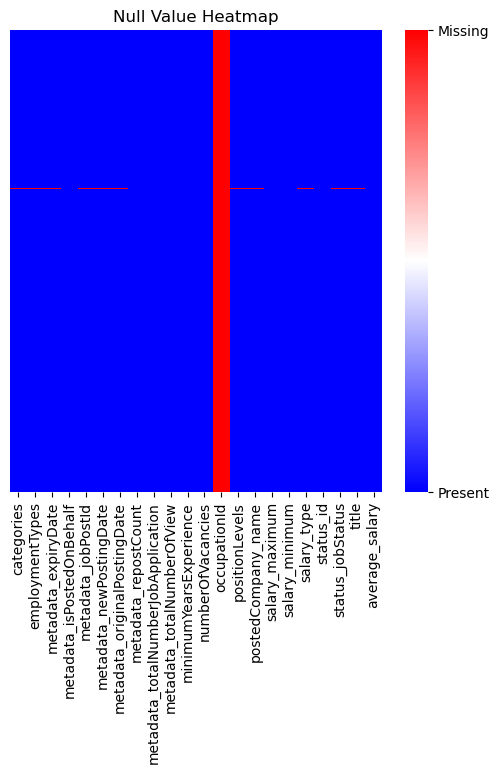

In [36]:
# visualize the null values
plt.figure(figsize=(6, 6))
ax = sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='bwr', cbar_kws={'ticks': [0, 1]})
ax.collections[0].colorbar.set_ticklabels(['Present', 'Missing'])
plt.title('Null Value Heatmap')
plt.show()  

#### Dive into the null values

In [37]:
# 1. Identify the rows that have null values
print (df.isna().sum(axis=1).value_counts())

mask = df.isna().sum(axis=1) == 12
df_3988 = df[mask]

df_3988.info()
# Shape, types, missing values at a glance
# with pd.option_context('display.float_format', '{:,.2f}'.format):
#     print(f"Rows: {df_3988.shape[0]:,}  Columns: {df_3988.shape[1]}")
#     print("\nNull counts:\n", df_3988.isnull().sum().sort_values(ascending=False).head(10))
#     print("\nBasic stats:\n", df_3988[['salary_minimum','salary_maximum','average_salary',
#                                 'minimumYearsExperience','numberOfVacancies']].describe())

1     1044597
12       3988
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 3988 entries, 197478 to 606701
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   categories                          0 non-null      object        
 1   employmentTypes                     0 non-null      object        
 2   metadata_expiryDate                 0 non-null      datetime64[ns]
 3   metadata_isPostedOnBehalf           3988 non-null   bool          
 4   metadata_jobPostId                  0 non-null      object        
 5   metadata_newPostingDate             0 non-null      datetime64[ns]
 6   metadata_originalPostingDate        0 non-null      datetime64[ns]
 7   metadata_repostCount                3988 non-null   int64         
 8   metadata_totalNumberJobApplication  3988 non-null   int64         
 9   metadata_totalNumberOfView          3988

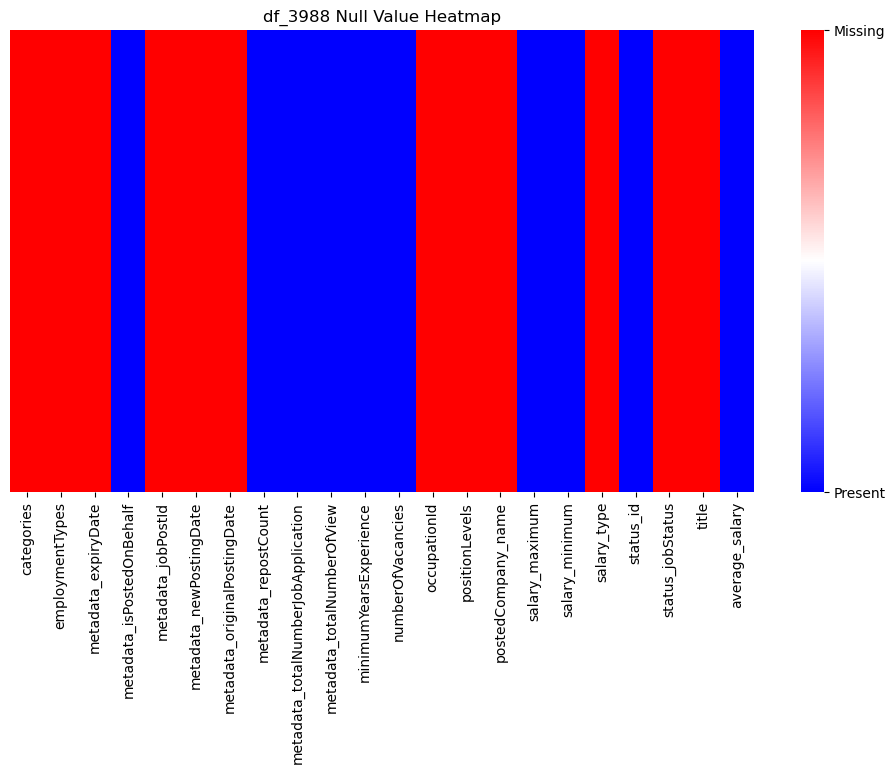

,metadata_expiryDate,metadata_newPostingDate,metadata_originalPostingDate,metadata_repostCount,metadata_totalNumberJobApplication,metadata_totalNumberOfView,minimumYearsExperience,numberOfVacancies,occupationId,salary_maximum,salary_minimum,status_id,average_salary
count,0,0,0,3988.0,3988.0,3988.0,3988.0,3988.0,0.0,3988.0,3988.0,3988.0,3988.0
mean,NaT,NaT,NaT,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
min,NaT,NaT,NaT,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
25%,NaT,NaT,NaT,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
50%,NaT,NaT,NaT,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
75%,NaT,NaT,NaT,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
max,NaT,NaT,NaT,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0
std,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0


In [38]:
# and a quick view on df_3988
plt.figure(figsize=(12, 6))
ax = sns.heatmap(df_3988.isnull(), cbar=True, yticklabels=False, cmap='bwr', cbar_kws={'ticks': [0, 1]})
ax.collections[0].colorbar.set_ticklabels(['Present', 'Missing'])
plt.title('df_3988 Null Value Heatmap')
plt.show()  

df_3988.describe()


#### outlier in salary

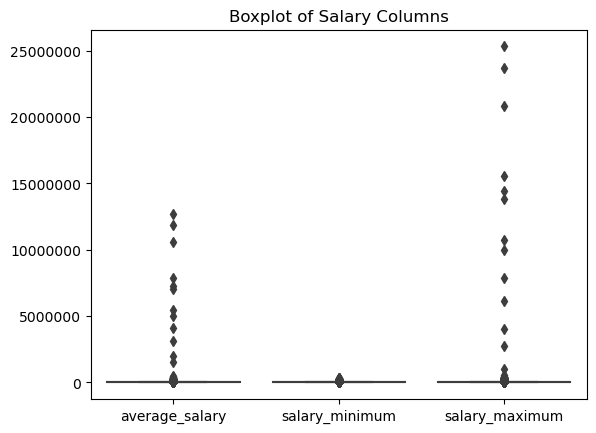

percentile in 25, 50, 75, 90, 95, 99
average salary: [ 2900.   3800.   5500.   8250.  10499.5 16666.5]
salary minimum: [ 2500.  3000.  4500.  6500.  8000. 13000.]
salary maximum: [ 3300.  4500.  6500. 10000. 12000. 20000.]


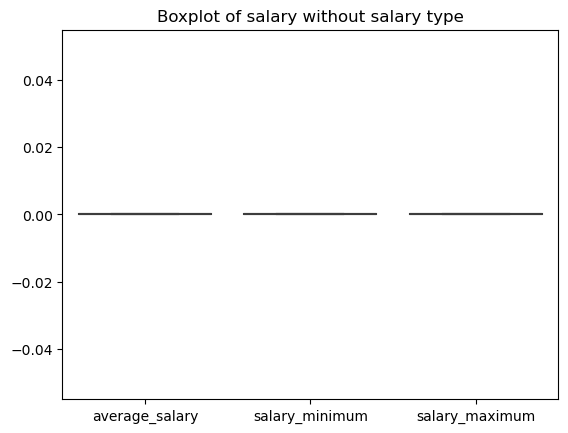

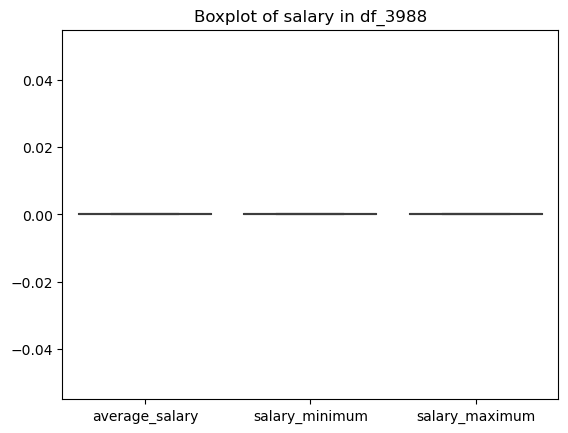

In [39]:
sns.boxplot(df[['average_salary', 'salary_minimum', 'salary_maximum']])
plt.title('Boxplot of Salary Columns')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

print ('percentile in 25, 50, 75, 90, 95, 99')
print (f'average salary: {np.percentile(df["average_salary"], [25, 50, 75, 90, 95, 99])}')
print (f'salary minimum: {np.percentile(df["salary_minimum"], [25, 50, 75, 90, 95, 99])}')
print (f'salary maximum: {np.percentile(df["salary_maximum"], [25, 50, 75, 90, 95, 99])}')


df_null_salary_type = df[df['salary_type'].isna()]

sns.boxplot(df_null_salary_type[['average_salary', 'salary_minimum', 'salary_maximum']])
plt.title('Boxplot of salary without salary type')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

sns.boxplot(df_3988[['average_salary', 'salary_minimum', 'salary_maximum']])
plt.title('Boxplot of salary in df_3988')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [40]:
df_3988[['average_salary', 'salary_minimum', 'salary_maximum']].describe()

,average_salary,salary_minimum,salary_maximum
count,3988.0,3988.0,3988.0
mean,0.0,0.0,0.0
std,0.0,0.0,0.0
min,0.0,0.0,0.0
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0
max,0.0,0.0,0.0


#### outlier in years of experience and number of vacancies.

In [41]:
print ('percentile in 25, 50, 75, 90, 95, 99')
print (f'years of experiences: {np.percentile(df["minimumYearsExperience"], [25, 50, 75, 90, 95, 99])}')
print (f'number of vacancies: {np.percentile(df["numberOfVacancies"], [25, 50, 75, 90, 95, 99])}')

# Shows the count of posts for each vacancy value
print(df['numberOfVacancies'].value_counts(ascending=False).head(10))
print(df['numberOfVacancies'].value_counts(ascending=False).iloc[20:30])
print(df['numberOfVacancies'].value_counts(ascending=False).iloc[40:50])
print(df['minimumYearsExperience'].value_counts(ascending=True).head(10))


percentile in 25, 50, 75, 90, 95, 99
years of experiences: [ 1.  2.  4.  5.  8. 10.]
number of vacancies: [ 1.  1.  2.  5.  6. 20.]
numberOfVacancies
1     590242
2     195718
3     111947
5      64760
10     26547
4      24580
8       5542
6       5456
20      5162
0       3988
Name: count, dtype: int64
numberOfVacancies
14     158
80     149
70     136
60     133
13     128
18     117
28     112
19      97
200     83
999     78
Name: count, dtype: int64
numberOfVacancies
35     30
150    30
49     24
32     24
36     23
23     22
33     20
48     18
120    16
38     15
Name: count, dtype: int64
minimumYearsExperience
58    1
60    1
76    1
47    1
38    1
63    1
62    1
55    2
56    2
24    2
Name: count, dtype: int64


#### checking duplicates

##### row

In [42]:
df.duplicated().sum() # expect 0 duplicates

3987

##### Job ID

In [43]:
# subset='metadata_jobPostId'
df['metadata_jobPostId'].describe()

count              1044597
unique             1044597
top       MCF-2023-0252866
freq                     1
Name: metadata_jobPostId, dtype: object

In [44]:
# likely the MCF is a unique code.  
# Extract the alphabetical prefix before the first hyphen
prefixes = df['metadata_jobPostId'].str.extract(r'^([A-Z]+)-')[0]
print("ID Prefix Distribution:")
print(prefixes.value_counts())

ID Prefix Distribution:
0
MCF    1044463
ATS        124
Name: count, dtype: int64


In [45]:
# separate the prefix and numbers to different columns 

# Regex breakdown:
# (?P<prefix>[A-Z]+) -> Captures letters (MCF/ATS)
# (?P<year>\d{4})    -> Captures the 4-digit year
# (?P<sequence>\d+)  -> Captures the final numeric ID
pattern = r'(?P<id_prefix>[A-Z]+)-(?P<id_year>\d{4})-(?P<id_sequence>\d+)'

# Extract into new columns
id_parts = df['metadata_jobPostId'].str.extract(pattern)
df = pd.concat([df, id_parts], axis=1)

# Convert sequence to numeric for easier sorting/math
df['id_sequence'] = pd.to_numeric(df['id_sequence'])

In [46]:

# A more comprehensive health check per prefix
id_health = df.groupby('id_prefix').agg({
    'id_sequence': [
        'count',           # Total rows
        'nunique',         # Unique IDs (should match count if no duplicates)
        'min',             # Check the start of the sequence
        'max',             # Check the end of the sequence
    ]
})

print(id_health)

          id_sequence                          
                count nunique    min        max
id_prefix                                      
ATS               124     124  816.0   951756.0
MCF           1044463  809516    2.0  1077353.0


### Section 1 Summary ⭐

- Shape
    - Big dataset with ~1m rows, 12 columns
    - many numeric columns skewed due to outliers

- outliers
    - salary (min, max, average) extereme values
    - minimal years experiences
    - number of vacancies

- null values
    - salary_type has 1000+ null values
    - 3988 rows with 12 columns null
    - column occupation is null

- duplicates
    - there are no obvious duplicates in the dataset.
    - the jobid contains duplicates at the the ID without prefix, likely due to `reposting`.

## Section 2: Data Cleaning

### Action plan 

**based on section 1 findings**

| Category | Finding | Action |
| :--- | :--- | :--- |
| **Null Values** | salary_type has 1000+ nulls; 3,988 rows are entirely null across all columns; occupation is null. | 1.Drop the 3,988 empty rows; impute salary_type and occupation with "Unknown" or the mode to preserve data volume. |
| **Shape** | Big dataset with ~1m rows and 12 columns; many numeric columns are skewed due to outliers. | Refer to **Outliers** action
| **Outliers** | Extreme values identified in salary (min, max, average), minimal years of experience, and number of vacancies. | 2. Apply IQR-based filtering to cap extreme values and stabilize the distribution. |
| **Duplicates** | No obvious full-row duplicates; however, jobid contains duplicates when the prefix is removed. | NA.  *No actions needed for persona D business analysis*

### Action 1: Drop the 3988 rows with 12 nulls in a row

In [47]:
# drop rows with 12 nulls in a row 

# df.drop(df_3988.index, inplace=True) 
# getting the index one more time to be safe
df_clean = df.drop(df[df.isna().sum(axis=1) == 12].index)

rows_before = len(df)
rows_after = len(df_clean)
rows_impacted = rows_before - rows_after

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning: {rows_after:,}")
print(f"Total rows impacted (removed): {rows_impacted:,}")


Rows before cleaning: 1,048,585
Rows after cleaning: 1,048,585
Total rows impacted (removed): 0


### Action 2: Normalize outliers and useful insights
**Executing cheat sheet for handling previous mentioned landmines:  **
[View landmines](#known-data-quality-landmines)


#### Salary cleaning


In [48]:
# Remove obvious outliers using the 99th percentile
p99 = np.percentile(df_clean['average_salary'].dropna(), 99)
df_clean = df[(df_clean['average_salary'] > 500) & (df_clean['average_salary'] <= p99)].copy()

# Use NumPy to compute stats on the cleaned array
sal = df_clean['average_salary'].to_numpy()
print(f"Mean: {np.mean(sal):,.0f}  Median: {np.median(sal):,.0f}  Std: {np.std(sal):,.0f}")
print(f"25th pct: {np.percentile(sal, 25):,.0f}  75th pct: {np.percentile(sal, 75):,.0f}")
print (f'max salary after cleaning: {np.max(sal):,.0f}')

rows_before = len(df)
rows_after = len(df_clean)
rows_impacted = rows_before - rows_after

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning: {rows_after:,}")
print(f"Total rows impacted (removed): {rows_impacted:,}")


Mean: 4,551  Median: 3,800  Std: 2,533
25th pct: 2,900  75th pct: 5,500
max salary after cleaning: 16,666
Rows before cleaning: 1,048,585
Rows after cleaning: 1,026,576
Total rows impacted (removed): 22,009


#### years of experience and number of vacancies cleaning
- minimal_years_experience: should be < 30 years 
- number_of_vacancies: number of positions available: should be less than 99

In [49]:
rows_before = len(df_clean)

# Apply filters to drop rows with extreme outliers
df_clean = df_clean[
    (df_clean['minimumYearsExperience'] < 30) & 
    (df_clean['numberOfVacancies'] < 99)
].copy()

rows_after = len(df_clean)
rows_impacted = rows_before - rows_after

print(f"Rows before cleaning: {rows_before:,}")
print(f"Rows after cleaning: {rows_after:,}")
print(f"Total rows impacted (removed): {rows_impacted:,}")


Rows before cleaning: 1,026,576
Rows after cleaning: 1,024,366
Total rows impacted (removed): 2,210


#### Groupby aggregation — salary by position level:

In [50]:
salary_by_level = (
    df_clean
    .groupby('positionLevels')['average_salary']
    .agg(['mean', 'median', 'count'])
    .rename(columns={'mean': 'avg_salary', 'median': 'median_salary', 'count': 'num_jobs'})
    .sort_values('median_salary', ascending=False)
)
print(salary_by_level)

                    avg_salary  median_salary  num_jobs
positionLevels                                         
Senior Management  9162.976830         8750.0     19616
Middle Management  7016.850737         6300.0     25914
Manager            6604.952048         6000.0    108327
Professional       6649.433110         6000.0    108424
Senior Executive   5591.766109         5000.0     99153
Executive          4120.923967         3750.0    252106
Junior Executive   3380.420406         3150.0    166665
Non-executive      3001.315158         2750.0    129067
Fresh/entry level  2792.381705         2600.0    115094


#### Parsing the `categories` JSON string (one row → first category):

* apply on df_clean 

In [51]:
import re

def extract_first_category(cat_str):
    """Extract the first category label from the JSON-like string."""
    if pd.isna(cat_str):
        return np.nan
    match = re.search(r'"category"\s*:\s*"([^"]+)"', str(cat_str))
    return match.group(1) if match else np.nan

df_clean['primary_category'] = df_clean['categories'].apply(extract_first_category)
print(df_clean['primary_category'].value_counts().head(10))


primary_category
Admin / Secretarial                 101470
Engineering                          99038
Information Technology               97653
Accounting / Auditing / Taxation     77273
Building and Construction            73620
Customer Service                     63695
F&B                                  58709
Banking and Finance                  44004
Logistics / Supply Chain             43994
Sales / Retail                       36564
Name: count, dtype: int64


#### Identify recruitment agencies (rough heuristic):

* add a new boolean column, direct, to indicate drect employers vs recruitment agencies.

In [52]:
agency_keywords = ['RECRUIT', 'HR ADVISORY', 'MANPOWER', 'STAFFING', 'CONSULT', 'TALENT']
pattern = '|'.join(agency_keywords)

direct_only = df_clean[
    (~df_clean['postedCompany_name'].str.upper().str.contains(pattern, na=False)) &
    (df_clean['metadata_isPostedOnBehalf'] == False)
]

direct_only

df_clean['direct'] = ~(
    df_clean['postedCompany_name'].str.upper().str.contains(pattern, na=False) |
    (df_clean['metadata_isPostedOnBehalf'] == True)
)   


### cleaned data verification

In [53]:
#  profiling

# Shape, types, missing values at a glance
with pd.option_context('display.float_format', '{:,.2f}'.format):
    print(f"Rows: {df_clean.shape[0]:,}  Columns: {df_clean.shape[1]}")
    print("\nNull counts:\n", df_clean.isnull().sum().sort_values(ascending=False).head(10))
    print("\nBasic stats:\n", df_clean[['salary_minimum','salary_maximum','average_salary',
                                'minimumYearsExperience','numberOfVacancies']].describe())

Rows: 1,024,366  Columns: 27

Null counts:
 occupationId          1024366
categories                  0
postedCompany_name          0
primary_category            0
id_sequence                 0
id_year                     0
id_prefix                   0
average_salary              0
title                       0
status_jobStatus            0
dtype: int64

Basic stats:
        salary_minimum  salary_maximum  average_salary  minimumYearsExperience  \
count    1,024,366.00    1,024,366.00    1,024,366.00            1,024,366.00   
mean         3,710.98        5,394.23        4,552.60                    2.74   
std          2,012.73        3,157.12        2,533.77                    2.41   
min              1.00          504.00          500.50                    0.00   
25%          2,500.00        3,300.00        2,900.00                    1.00   
50%          3,000.00        4,500.00        3,800.00                    2.00   
75%          4,500.00        6,500.00        5,500.00        

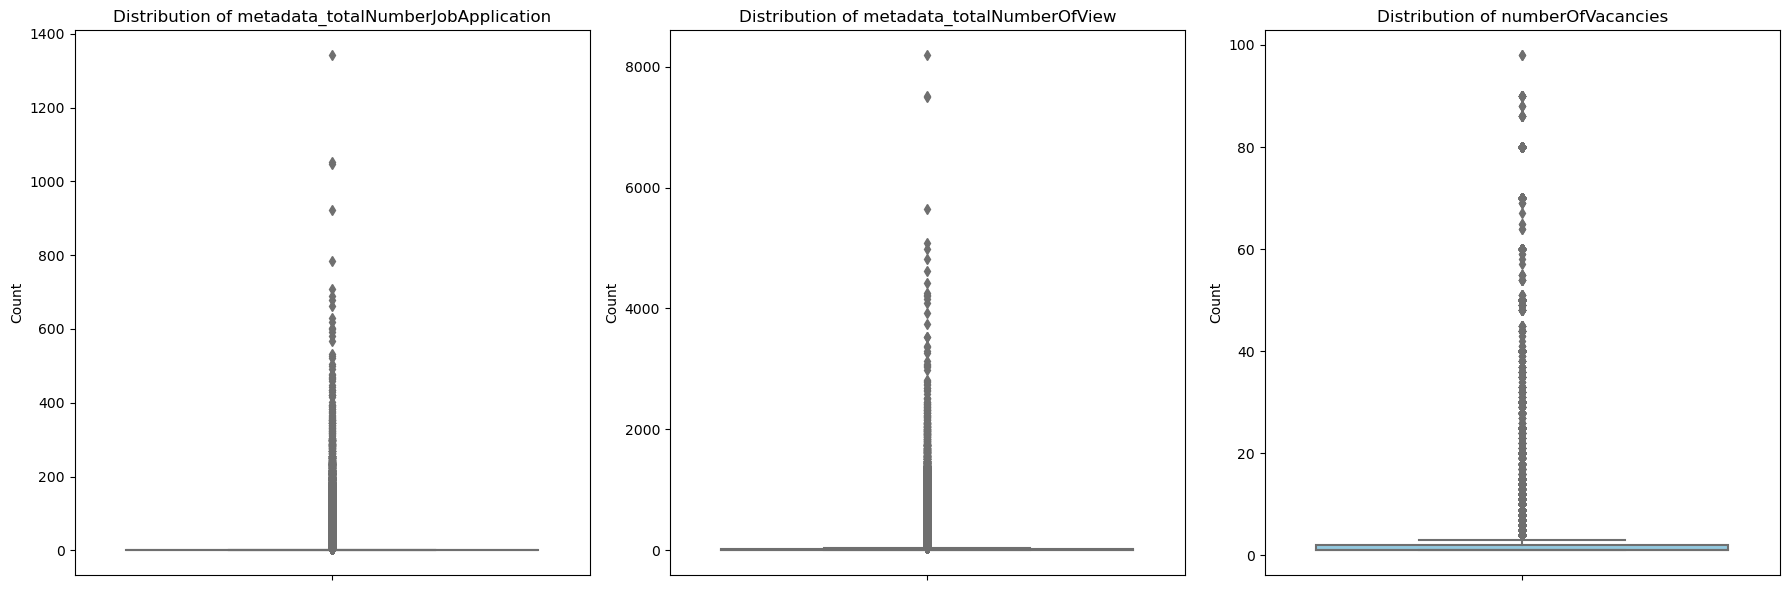

In [54]:
# remove the unsed data for persona D. 

# categories                                    object
# employmentTypes                               object
# metadata_expiryDate                   datetime64[ns]
# metadata_isPostedOnBehalf                       bool
# metadata_jobPostId                            object
# metadata_newPostingDate               datetime64[ns]
# metadata_originalPostingDate          datetime64[ns]
# metadata_repostCount                           int64
# metadata_totalNumberJobApplication             int64
# metadata_totalNumberOfView                     int64
# minimumYearsExperience                         int64
# numberOfVacancies                              int64
# occupationId                                 float64
# positionLevels                                object
# postedCompany_name                            object
# salary_maximum                                 int64
# salary_minimum                                 int64
# salary_type                                   object
# status_id                                      int64
# status_jobStatus                              object
# title                                         object
# average_salary                               float64
# primary_category                              object
# year_month                                 period[M]
# day_of_week                                   object
# month_of_year                              period[M]
# direct                                          bool
# columns_to_analyse=['metadata_totalNumberJobApplication'
#                     , 'metadata_totalNumberOfView', 'numberOfVacancies'
#                     , 'title', 'day_of_week', 'month_of_year'
#                     , 'positionLevels', 'average_salary'
#                     , 'year_month']
# df_export = df_clean[columns_to_analyse]

df_clean.describe().style.format("{:,.2f}")

# 1. List the columns you want to visualize
cols_to_plot = ['metadata_totalNumberJobApplication', 'metadata_totalNumberOfView', 'numberOfVacancies']

# 2. Create side-by-side boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cols_to_plot):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()






### Section 2 Summary ⭐

**based on section 1 findings**

| Category | Finding | Action | Impacted Rows |
| :--- | :--- | :--- | :--- |
| **Null Values** | salary_type has 1000+ nulls; 3,988 rows are entirely null across all columns; occupation is null. | 1.Drop the 3,988 empty rows; impute salary_type and occupation with "Unknown" or the mode to preserve data volume. | 3988 rows |
| **Outliers** | Salary(min, max, average), vacancies, and min years of experience showed extreme skewed distributions. | Drop rows by **Cap** average salary at 500 and 99th percentile; **cap vacancies** at 99; **cap experience** at 30 years.  | 22009 and 2210 | 
| **Duplicates** | No obvious full-row duplicates; however, jobid contains duplicates when the prefix is removed. | NA.  *No actions for reposting*
| **Refined Columns** | Standardizing core numeric features for salary and requirements. | Validated `salary_minimum`, `salary_maximum`, `salary_average`, `minimal_years_experience`, and `number_of_vacancies`. | |
| **New Features (Time)** | Need to analyze "When to Apply" trends based on original posting dates. | Extracted `year_month`, `day_of_week` (e.g., Monday), and `month_of_year` (e.g., January). | |
| **New Features (Meta)** | Extracting structural info from JSON and metadata strings. | Created `primary_category` (from JSON) and `direct` (Boolean: True for direct hire, False for agency). | |

### export CSV

In [55]:
# export csv
df_clean.to_csv('data/SGJobData_cleaned.csv', index=False)

## Section 3: Data Refinement for Business Questions

#### Monthly posting trend:

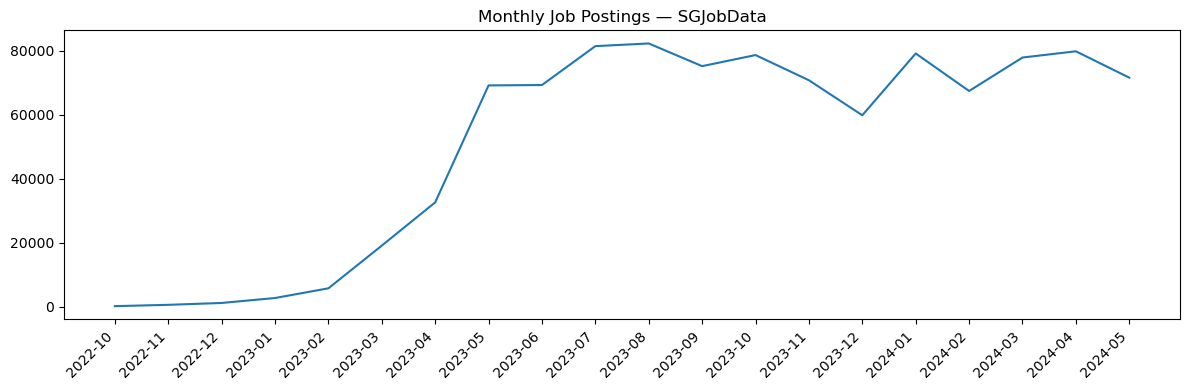

In [56]:
df_clean['year_month'] = df_clean['metadata_originalPostingDate'].dt.to_period('M')
monthly = df_clean.groupby('year_month').size().reset_index(name='postings')

plt.figure(figsize=(12, 4))
plt.plot(monthly['year_month'].astype(str), monthly['postings'])
plt.xticks(rotation=45, ha='right')
plt.title('Monthly Job Postings — SGJobData')
plt.tight_layout()
plt.show()


#### day of week vs job posting

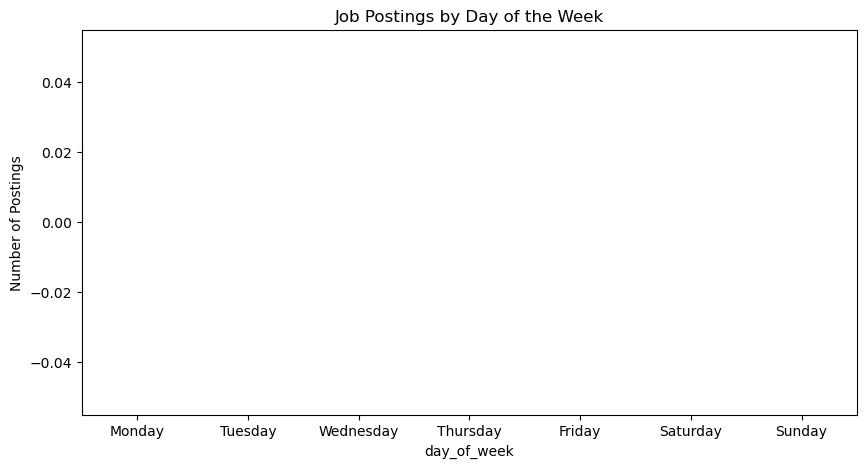

In [57]:
df_clean['day_of_week'] = df_clean['metadata_originalPostingDate'].dt.dayofweek # 1 to 7 for Mon to Sun
df_clean['month_of_year'] = df_clean['metadata_originalPostingDate'].dt.month # 1 to 12 for Jan to Dec

# 1. Count postings per day
day_counts = df_clean['day_of_week'].value_counts()

# 2. Sort them in calendar order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = day_counts.reindex(days_order)
# 3. Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis')
plt.title('Job Postings by Day of the Week')
plt.ylabel('Number of Postings')
plt.show()


#### Correlation heatmap:


##### example


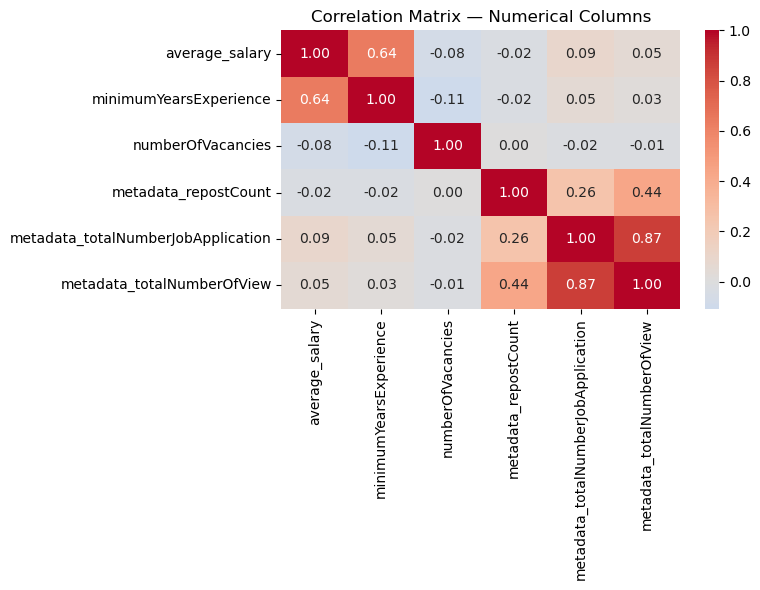

In [58]:
num_cols = ['average_salary', 'minimumYearsExperience', 'numberOfVacancies',
            'metadata_repostCount', 'metadata_totalNumberJobApplication',
            'metadata_totalNumberOfView']
corr = df_clean[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numerical Columns')
plt.tight_layout()
plt.show()


##### date, title, application views, post

categories                                    object
employmentTypes                               object
metadata_expiryDate                   datetime64[ns]
metadata_isPostedOnBehalf                       bool
metadata_jobPostId                            object
metadata_newPostingDate               datetime64[ns]
metadata_originalPostingDate          datetime64[ns]
metadata_repostCount                           int64
metadata_totalNumberJobApplication             int64
metadata_totalNumberOfView                     int64
minimumYearsExperience                         int64
numberOfVacancies                              int64
occupationId                                 float64
positionLevels                                object
postedCompany_name                            object
salary_maximum                                 int64
salary_minimum                                 int64
salary_type                                   object
status_id                                     

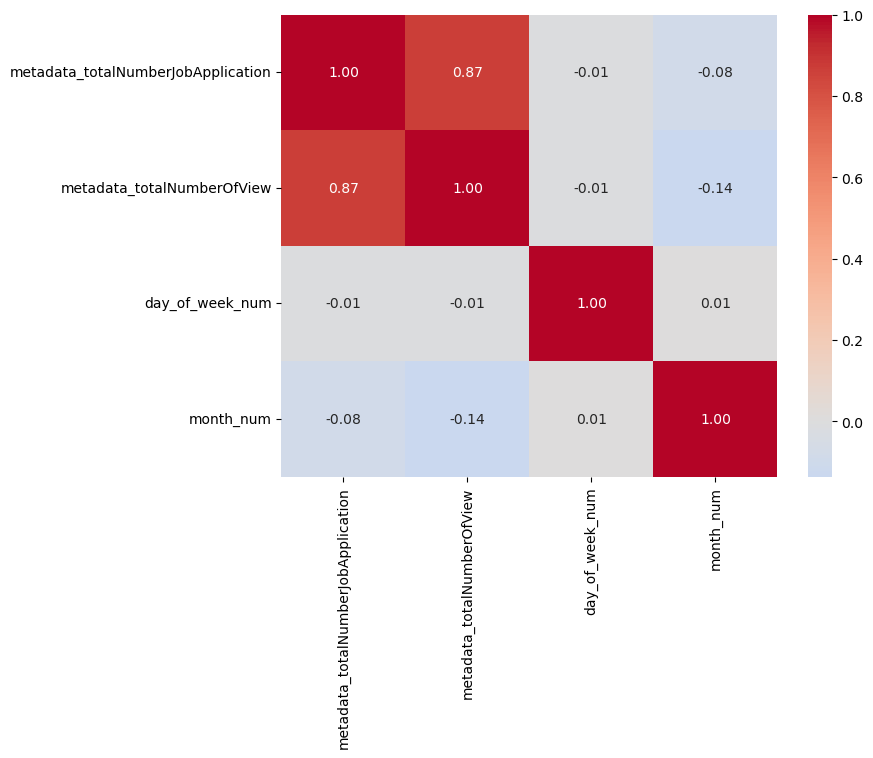

In [59]:
print(df_clean.dtypes)

num_cols = ['metadata_totalNumberJobApplication',
            'metadata_totalNumberOfView', 'title', 'day_of_week', 'month_of_year']


# Convert text/periods to temporary numbers for the correlation check
df_corr_temp = df_clean[num_cols].copy()
df_corr_temp['day_of_week_num'] = df_corr_temp['day_of_week'].astype('category').cat.codes
df_corr_temp['month_num'] = df_corr_temp['month_of_year'].astype('category').cat.codes

# Update your list to use the new numeric versions
plot_cols = ['metadata_totalNumberJobApplication', 'metadata_totalNumberOfView', 
             'day_of_week_num', 'month_num']

corr = df_corr_temp[plot_cols].corr()

# Now run your heatmap code
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()


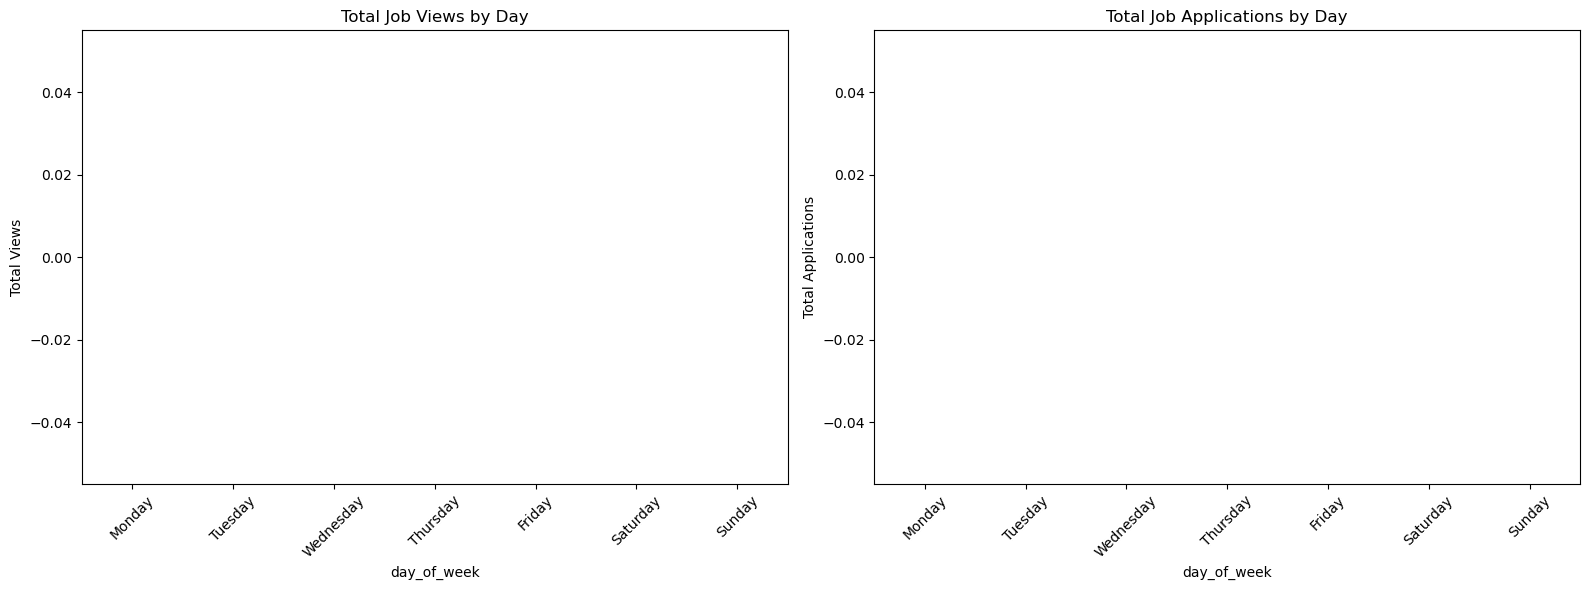

In [60]:
# 1. Prepare the data (using sum for total counts)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_totals = df_clean.groupby('day_of_week')[['metadata_totalNumberOfView', 'metadata_totalNumberJobApplication']].sum().reindex(days_order)

# 2. Create the two side-by-side bar charts
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Total Views by Day
sns.barplot(x=day_totals.index, y=day_totals['metadata_totalNumberOfView'], ax=ax[0], palette='Blues_r')
ax[0].set_title('Total Job Views by Day')
ax[0].set_ylabel('Total Views')
ax[0].tick_params(axis='x', rotation=45)

# Plot 2: Total Applications by Day
sns.barplot(x=day_totals.index, y=day_totals['metadata_totalNumberJobApplication'], ax=ax[1], palette='Oranges_r')
ax[1].set_title('Total Job Applications by Day')
ax[1].set_ylabel('Total Applications')
ax[1].tick_params(axis='x', rotation=45)

ax[0].ticklabel_format(style='plain', axis='y')
ax[1].ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

## Section 4: ❗ TEAM INPUT ❗ 

- One code block each. 
- Capture your outputs as visible notebook cells — you may refer to them in your presentation.

### Recap

- [issues identified in data](#section-1-summary-)
- [action performed to data](#section-2-summary-)

### Answer these six together as a team. 

#### 1. What is the
- the shape of the DataFrame, 
- the date range of metadata_originalPostingDate, 
- and how many unique job post IDs are there?


In [67]:
# General statistics and range
shape = df_clean.shape
date_min = df_clean['metadata_originalPostingDate'].min()
date_max = df_clean['metadata_originalPostingDate'].max()
unique_ids = df_clean['metadata_jobPostId'].nunique()

print(f"DataFrame Shape: {shape}")
print(f"Date Range: {date_min} to {date_max}")
print(f"Unique Job IDs: {unique_ids}")

DataFrame Shape: (1024366, 30)
Date Range: 2022-10-03 00:00:00 to 2024-05-29 00:00:00
Unique Job IDs: 1024366


#### 2. What are the top 10 most common primary_category values, and what percentage of all jobs does each represent? (Use .value_counts(normalize=True))


In [62]:
# 1. Get raw counts for the top 10
top_10_counts = df_clean['primary_category'].value_counts().head(10)

# 2. Get percentages (proportions * 100)
top_10_pct = df_clean['primary_category'].value_counts(normalize=True).head(10) * 100

# 3. Combine into a summary DataFrame
summary_categories = pd.DataFrame({
    'Count': top_10_counts,
    'Percentage (%)': top_10_pct.round(2)
})

print(summary_categories)

                                   Count  Percentage (%)
primary_category                                        
Admin / Secretarial               101470            9.91
Engineering                        99038            9.67
Information Technology             97653            9.53
Accounting / Auditing / Taxation   77273            7.54
Building and Construction          73620            7.19
Customer Service                   63695            6.22
F&B                                58709            5.73
Banking and Finance                44004            4.30
Logistics / Supply Chain           43994            4.29
Sales / Retail                     36564            3.57


#### 3. After removing salary outliers, what is the median average_salary broken down by positionLevels? Sort from highest to lowest.


In [74]:
# 1. Calculate medians BEFORE filtering by IQR
print("--- Median Salary BEFORE IQR Filtering IQR ---")
median_before = df_clean.groupby('positionLevels')['average_salary'].median().sort_values(ascending=False)
print(median_before)
print("\n")

# 2. Perform IQR Filtering
Q1 = df_clean['average_salary'].quantile(0.25)
Q3 = df_clean['average_salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

filtered_df = df_clean[(df_clean['average_salary'] >= lower_bound) & 
                       (df_clean['average_salary'] <= upper_bound)]

# 3. Calculate medians AFTER filtering
print("--- Median Salary AFTER IQR Filtering ---")
median_after = filtered_df.groupby('positionLevels')['average_salary'].median().sort_values(ascending=False)
print(median_after)

# Optional: Check how many rows were removed
print(f"\nRows removed as outliers: {len(df_clean) - len(filtered_df)}")

--- Median Salary BEFORE IQR Filtering IQR ---
positionLevels
Senior Management    8750.0
Middle Management    6300.0
Manager              6000.0
Professional         6000.0
Senior Executive     5000.0
Executive            3750.0
Junior Executive     3150.0
Non-executive        2750.0
Fresh/entry level    2600.0
Name: average_salary, dtype: float64


--- Median Salary AFTER IQR Filtering ---
positionLevels
Senior Management    7550.0
Manager              5750.0
Professional         5225.0
Senior Executive     5000.0
Middle Management    4750.0
Executive            3750.0
Junior Executive     3150.0
Non-executive        2750.0
Fresh/entry level    2600.0
Name: average_salary, dtype: float64

Rows removed as outliers: 60322


#### 4. Which 5 columns have the most missing values? What percentage of rows are null in each?


In [ ]:
# Raw data before cleaning 
# Identifying columns with the highest null counts
missing_values = df.isnull().sum().sort_values(ascending=False).head(5)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False).head(5)

missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage Null (%)': missing_pct.round(2)
})
print(missing_summary)

                    Missing Count  Percentage Null (%)
occupationId              1048585               100.00
id_prefix                    3998                 0.38
id_year                      3998                 0.38
id_sequence                  3998                 0.38
metadata_jobPostId           3988                 0.38


#### 5. What is the distribution of minimumYearsExperience? Plot a histogram. Where does the bulk of demand sit?


--- Descriptive Statistics: Minimum Years Experience ---
count   1024366.00
mean          2.74
std           2.41
min           0.00
25%           1.00
50%           2.00
75%           4.00
max          29.00
Name: minimumYearsExperience, dtype: float64


The bulk of demand sits at: 1 years of experience.


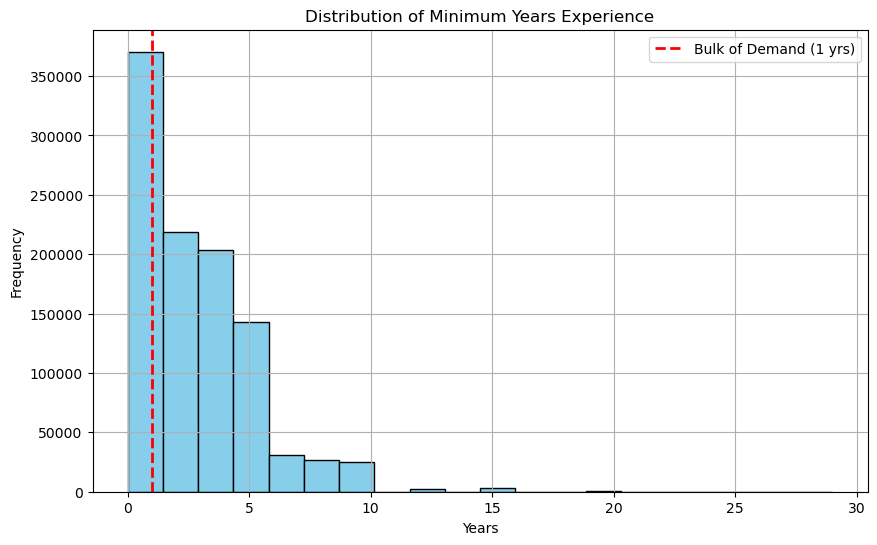

In [80]:
pd.options.display.float_format = '{:.2f}'.format

# 1. Show descriptive statistics in the terminal/console first
print("--- Descriptive Statistics: Minimum Years Experience ---")
print(df_clean['minimumYearsExperience'].describe())
print("\n")

# 2. Identify the 'Bulk of Demand' (The Mode)
bulk_demand = df_clean['minimumYearsExperience'].mode()[0]
print(f"The bulk of demand sits at: {bulk_demand} years of experience.")

# 3. Plot the histogram
plt.figure(figsize=(10, 6))
df_clean['minimumYearsExperience'].hist(bins=20, color='skyblue', edgecolor='black')

# Adding a vertical line to visualize the 'Bulk of Demand'
plt.axvline(bulk_demand, color='red', linestyle='dashed', linewidth=2, label=f'Bulk of Demand ({bulk_demand} yrs)')

plt.title('Distribution of Minimum Years Experience')
plt.xlabel('Years')
plt.ylabel('Frequency')
plt.legend()

#### 6. Compute the correlation between average_salary, minimumYearsExperience, metadata_repostCount, and metadata_totalNumberJobApplication. Which pair has the strongest relationship?


In [84]:
# Select the specific columns for correlation
cols_to_corr = [
    'average_salary', 
    'minimumYearsExperience', 
    'metadata_repostCount', 
    'metadata_totalNumberJobApplication'
]

# Compute the correlation matrix
corr_matrix = df_clean[cols_to_corr].corr()
corr_matrix


,average_salary,minimumYearsExperience,metadata_repostCount,metadata_totalNumberJobApplication
average_salary,1.00,0.64,-0.02,0.09
minimumYearsExperience,0.64,1.00,-0.02,0.05
metadata_repostCount,-0.02,-0.02,1.00,0.26
metadata_totalNumberJobApplication,0.09,0.05,0.26,1.00


### Answer to Business Question 

#### 1. **When to Apply?** 
Which days of the week and months of the year do job postings receive the most views and applications?

Data:
- Group by: day_of_week (0-6) and month_of_year (1-12).
- Metrics: Sum of metadata_totalNumberOfView and metadata_totalNumberJobApplication.


In [96]:
# 1. Group by Day of Week
day_stats = df_clean.groupby('day_of_week')[['metadata_totalNumberOfView', 'metadata_totalNumberJobApplication']].sum()

# 2. Group by Month of Year
month_stats = df_clean.groupby('month_of_year')[['metadata_totalNumberOfView', 'metadata_totalNumberJobApplication']].sum()

# Optional: Map numbers to names for better readability in terminal
days = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
months = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 
          7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

day_stats.index = day_stats.index.map(days)
month_stats.index = month_stats.index.map(months)

# 3. Show the results in terminal
print("--- Engagement by Day of Week ---")
print(day_stats.sort_values('metadata_totalNumberJobApplication', ascending=False))

print("\n--- Engagement by Month of Year ---")
print(month_stats.sort_values('metadata_totalNumberJobApplication', ascending=False))

--- Engagement by Day of Week ---
             metadata_totalNumberOfView  metadata_totalNumberJobApplication
day_of_week                                                                
Tue                             5430075                              439749
Thu                             5228725                              410874
Wed                             5121244                              407350
Mon                             4712641                              371651
Fri                             4606041                              368102
Sat                             1086704                               83630
Sun                              893047                               62858

--- Engagement by Month of Year ---
               metadata_totalNumberOfView  metadata_totalNumberJobApplication
month_of_year                                                                
May                               8120777                              701603
Jun        

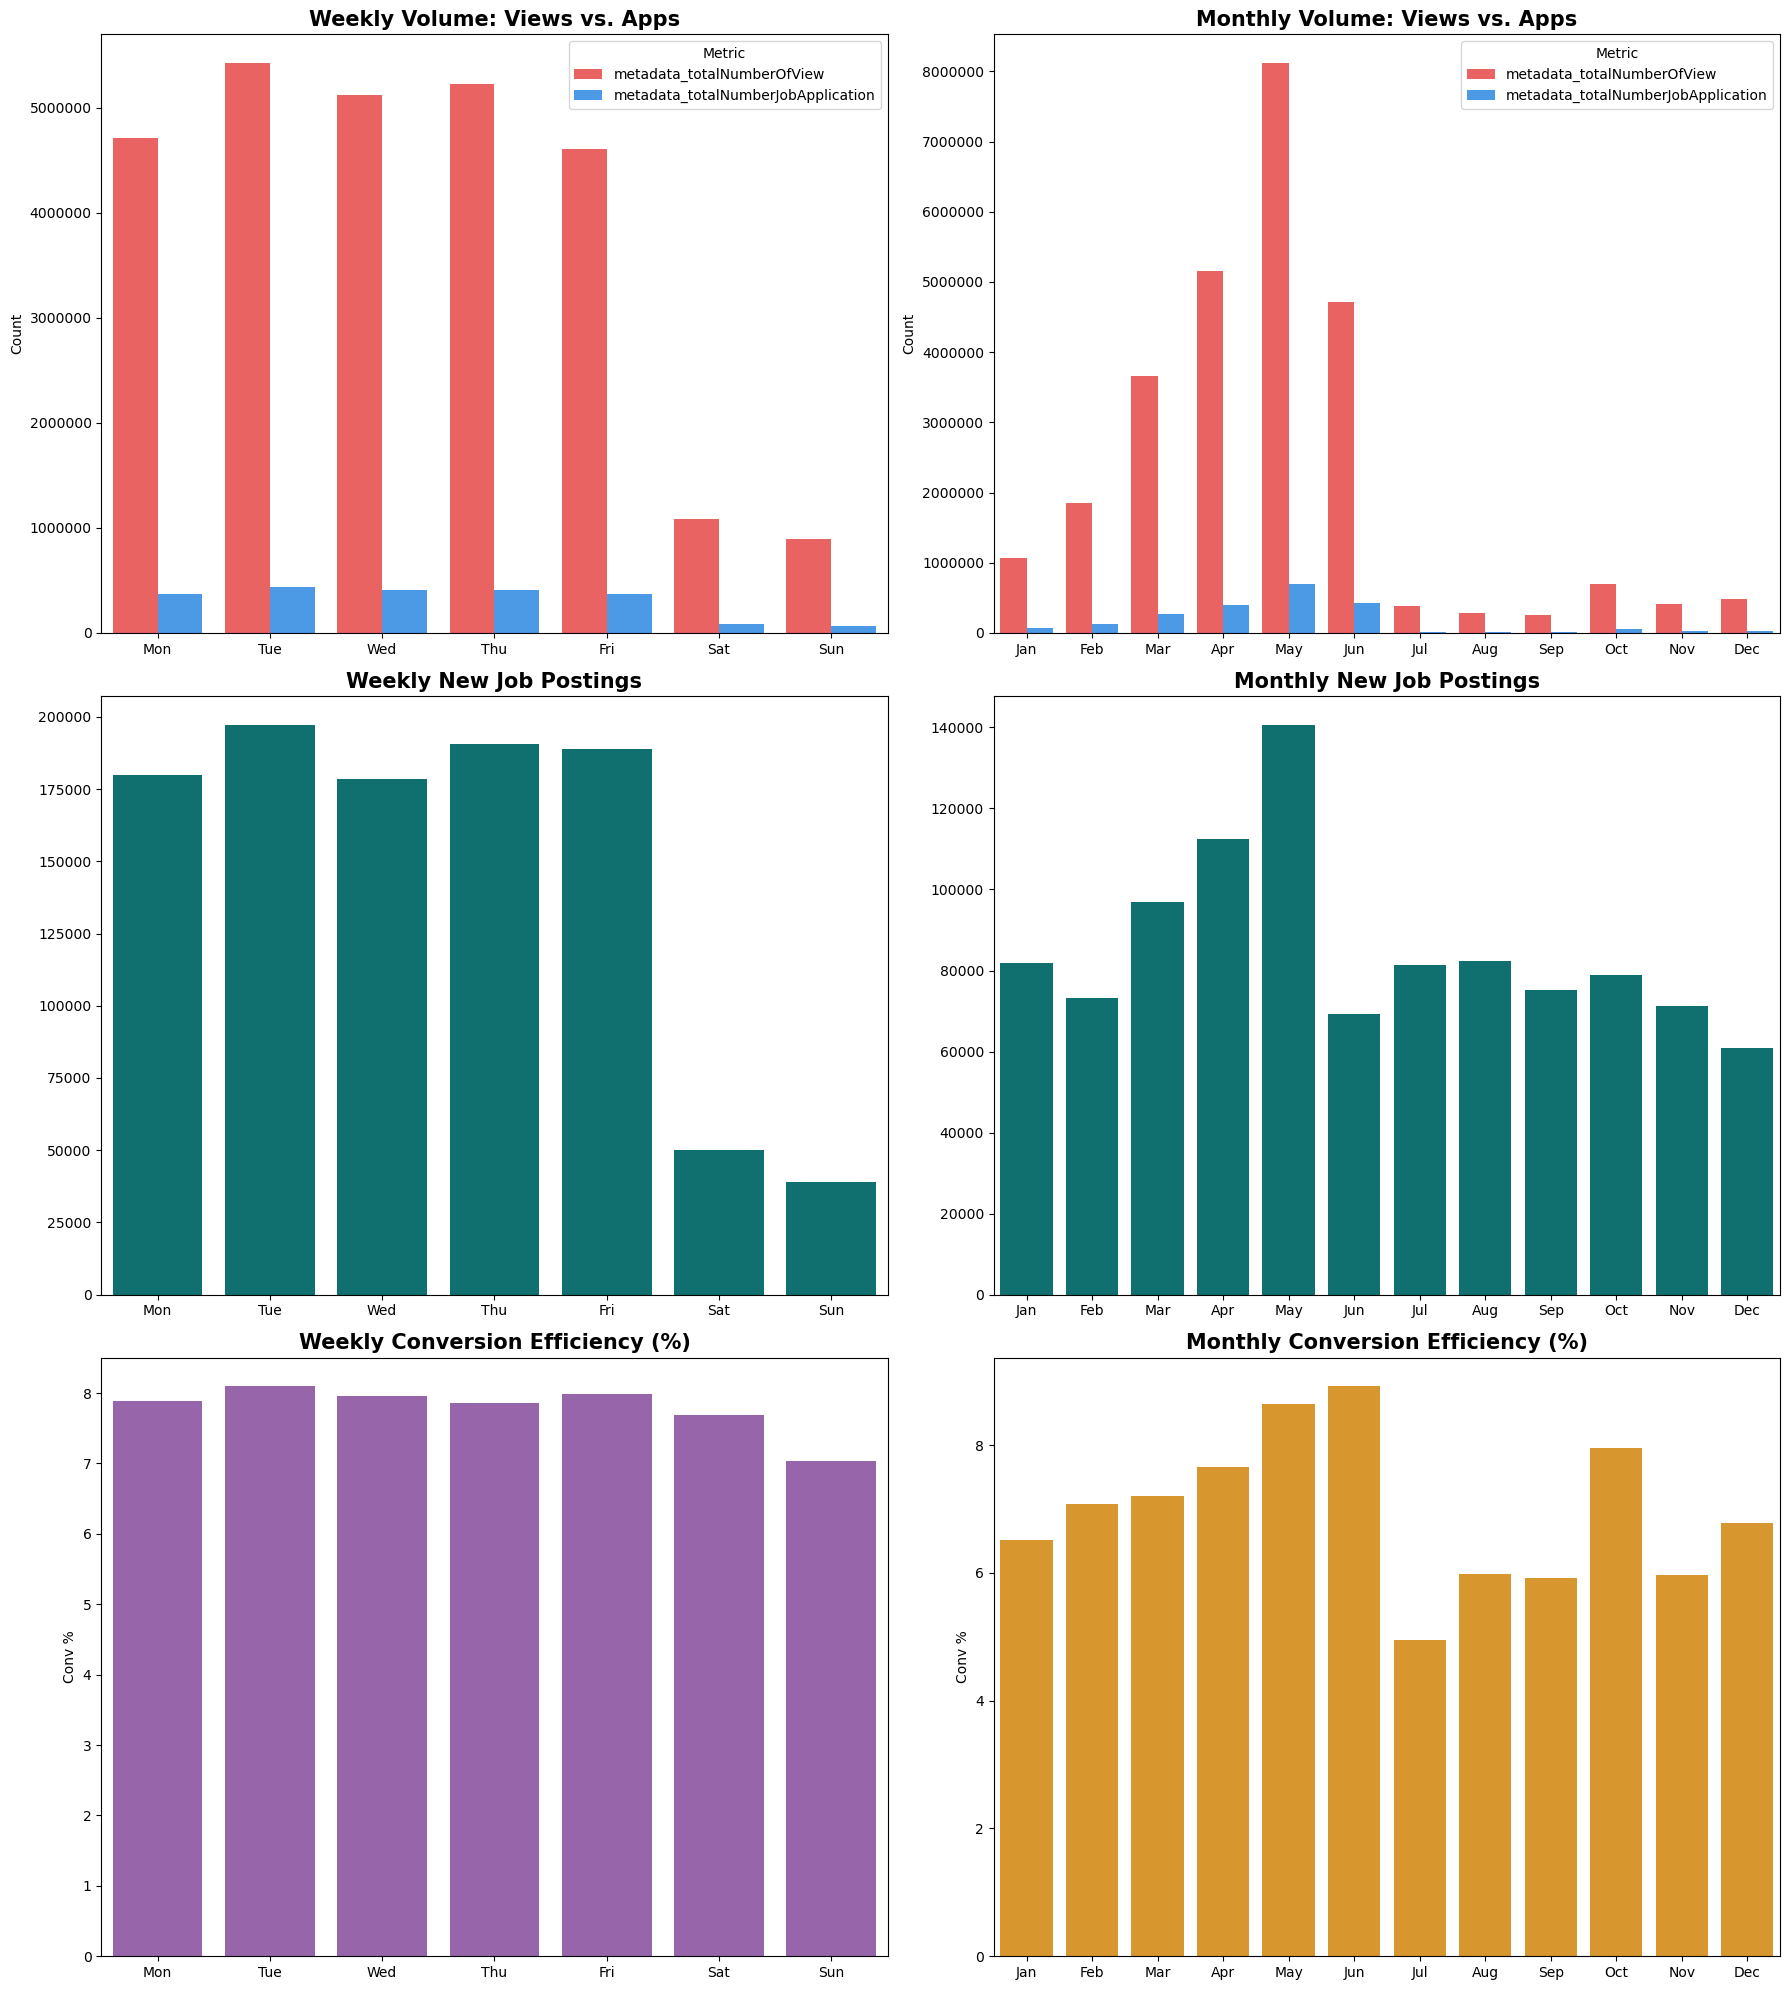


--- New Job Postings by Day ---
day_of_week
Mon    179844
Tue    197389
Wed    178458
Thu    190790
Fri    188765
Sat     50113
Sun     39007
dtype: int64

--- New Job Postings by Month ---
month_of_year
Jan     81849
Feb     73157
Mar     96950
Apr    112409
May    140725
Jun     69268
Jul     81429
Aug     82261
Sep     75175
Oct     78812
Nov     71343
Dec     60988
dtype: int64


In [100]:
# --- NEW SECTION: DATA COLLECTION FOR NEW POSTINGS ---
# We use .size() on the original groupby to get the count of postings
day_postings = df_clean.groupby('day_of_week').size()
month_postings = df_clean.groupby('month_of_year').size()

# Map names to match your existing logic
day_postings.index = day_postings.index.map(days)
month_postings.index = month_postings.index.map(months)

# Reindex to ensure chronological order for the charts
day_postings = day_postings.reindex(days.values())
month_postings = month_postings.reindex(months.values())

# --- NEW SECTION: 3-ROW CHART GENERATION ---
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

# Prepare plotting dataframes
df_day_plt = day_stats.reset_index().rename(columns={'index': 'day_of_week'})
df_month_plt = month_stats.reset_index().rename(columns={'index': 'month_of_year'})

# Calculate Conversion % for Row 3
df_day_plt['Conv %'] = (df_day_plt['metadata_totalNumberJobApplication'] / df_day_plt['metadata_totalNumberOfView']) * 100
df_month_plt['Conv %'] = (df_month_plt['metadata_totalNumberJobApplication'] / df_month_plt['metadata_totalNumberOfView']) * 100

# Melt volume data for Row 1
day_melt = df_day_plt.melt(id_vars='day_of_week', value_vars=['metadata_totalNumberOfView', 'metadata_totalNumberJobApplication'], var_name='Metric', value_name='Count')
month_melt = df_month_plt.melt(id_vars='month_of_year', value_vars=['metadata_totalNumberOfView', 'metadata_totalNumberJobApplication'], var_name='Metric', value_name='Count')

# Setup 3x2 Grid
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
vol_pal = ['#ff4d4d', '#3399ff'] # Red/Blue
post_col = '#008080'             # Teal for Postings

# ROW 1: Market Volume (Sum)
sns.barplot(ax=axes[0, 0], data=day_melt, x='day_of_week', y='Count', hue='Metric', palette=vol_pal)
sns.barplot(ax=axes[0, 1], data=month_melt, x='month_of_year', y='Count', hue='Metric', palette=vol_pal)
axes[0, 0].set_title('Weekly Volume: Views vs. Apps', fontweight='bold', fontsize=15)
axes[0, 1].set_title('Monthly Volume: Views vs. Apps', fontweight='bold', fontsize=15)

# ROW 2: New Job Postings (Count)
sns.barplot(ax=axes[1, 0], x=day_postings.index, y=day_postings.values, color=post_col)
sns.barplot(ax=axes[1, 1], x=month_postings.index, y=month_postings.values, color=post_col)
axes[1, 0].set_title('Weekly New Job Postings', fontweight='bold', fontsize=15)
axes[1, 1].set_title('Monthly New Job Postings', fontweight='bold', fontsize=15)

# ROW 3: Conversion Efficiency (%)
sns.barplot(ax=axes[2, 0], data=df_day_plt, x='day_of_week', y='Conv %', color='#9b59b6')
sns.barplot(ax=axes[2, 1], data=df_month_plt, x='month_of_year', y='Conv %', color='#f39c12')
axes[2, 0].set_title('Weekly Conversion Efficiency (%)', fontweight='bold', fontsize=15)
axes[2, 1].set_title('Monthly Conversion Efficiency (%)', fontweight='bold', fontsize=15)

# Final Formatting
for ax in axes.flat:
    ax.ticklabel_format(style='plain', axis='y')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

# Print the new data to terminal
print("\n--- New Job Postings by Day ---")
print(day_postings)
print("\n--- New Job Postings by Month ---")
print(month_postings)

/Users/ethan/miniconda3/envs/pds/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ethan/miniconda3/envs/pds/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ethan/miniconda3/envs/pds/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/ethan/miniconda3/envs/pds/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and wil

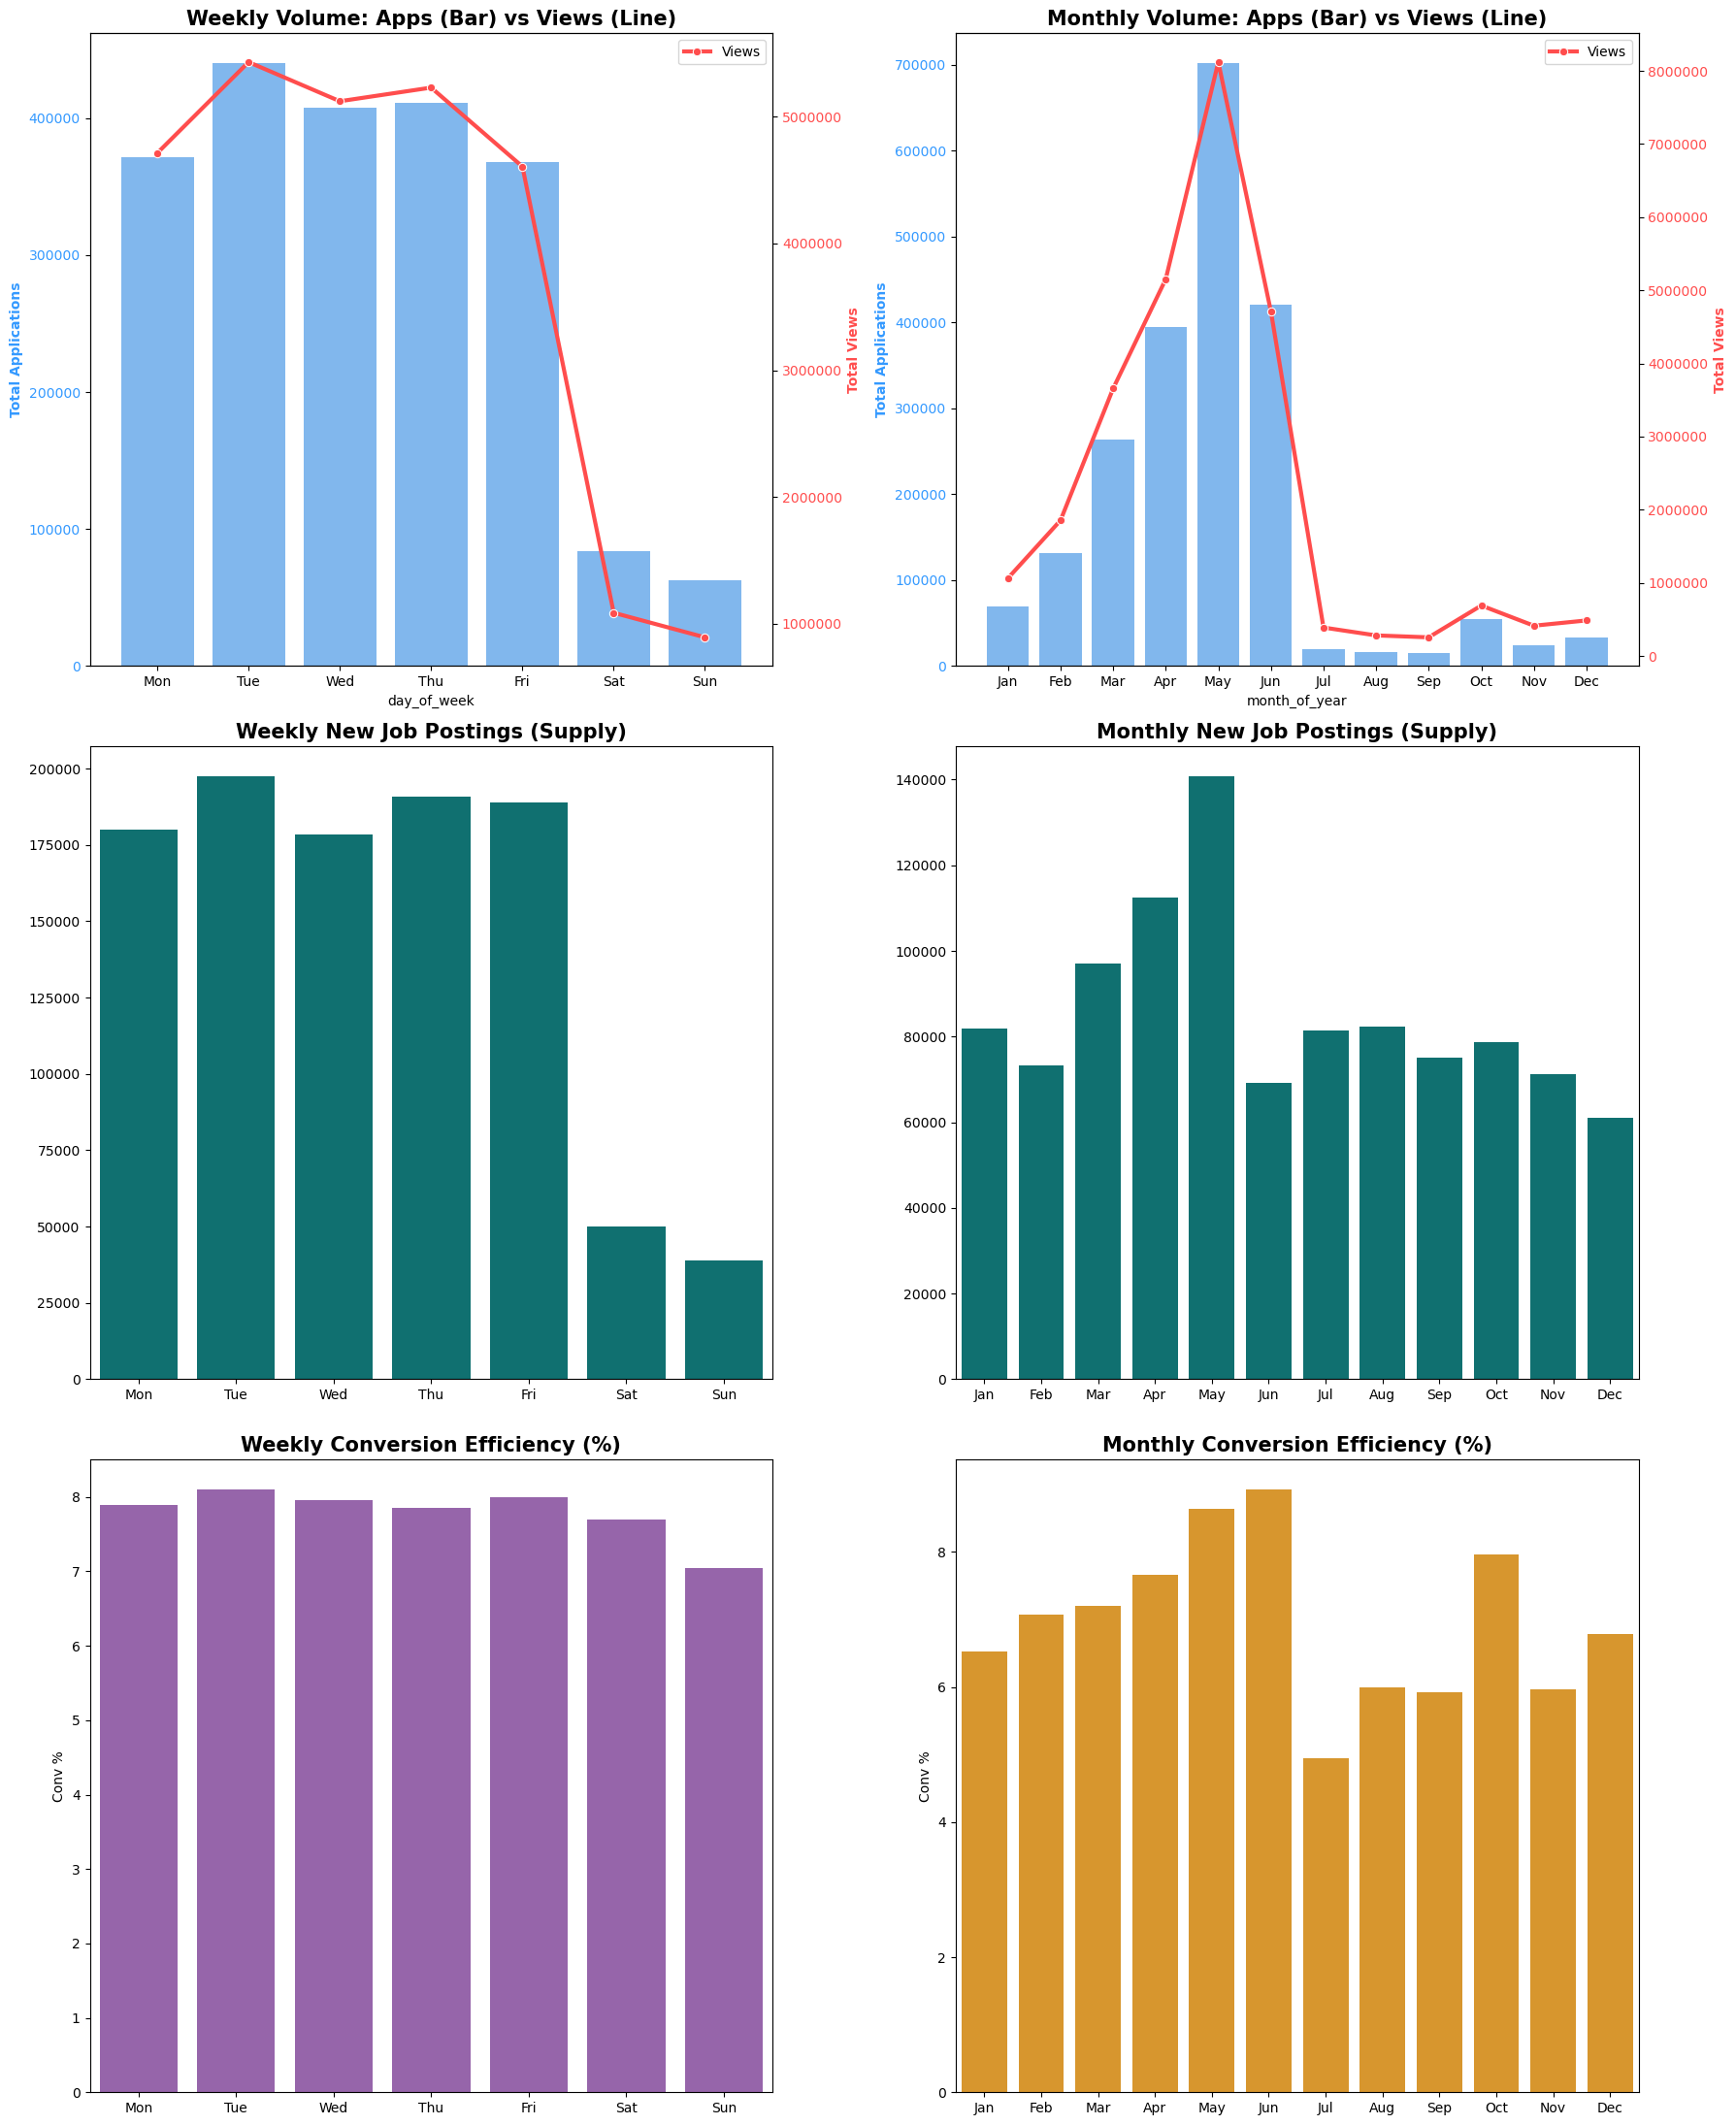

--- Engagement by Day of Week ---
             metadata_totalNumberOfView  metadata_totalNumberJobApplication
day_of_week                                                                
Tue                             5430075                              439749
Thu                             5228725                              410874
Wed                             5121244                              407350
Mon                             4712641                              371651
Fri                             4606041                              368102
Sat                             1086704                               83630
Sun                              893047                               62858

--- Engagement by Month of Year ---
               metadata_totalNumberOfView  metadata_totalNumberJobApplication
month_of_year                                                                
May                               8120777                              701603
Jun        

In [106]:


# ==========================================
# 1. DATA COLLECTION & GROUPING
# ==========================================

# --- Original Volume Stats (Sum) ---
day_stats = df_clean.groupby('day_of_week')[['metadata_totalNumberOfView', 'metadata_totalNumberJobApplication']].sum()
month_stats = df_clean.groupby('month_of_year')[['metadata_totalNumberOfView', 'metadata_totalNumberJobApplication']].sum()

# --- New Job Postings Section (Count) ---
day_postings = df_clean.groupby('day_of_week').size()
month_postings = df_clean.groupby('month_of_year').size()

# Mapping Dictionaries
days = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
months = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 
          7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

# Map the names to all DataFrames
day_stats.index = day_stats.index.map(days)
month_stats.index = month_stats.index.map(months)
day_postings.index = day_postings.index.map(days)
month_postings.index = month_postings.index.map(months)

# Reindex to ensure chronological order for the charts
day_postings = day_postings.reindex(days.values())
month_postings = month_postings.reindex(months.values())

# ==========================================
# 2. DATA PREPARATION FOR DASHBOARD
# ==========================================

# Rename columns for clarity and to avoid KeyErrors in plotting
df_day_plt = day_stats.reset_index().rename(columns={
    'index': 'day_of_week',
    'metadata_totalNumberOfView': 'Views',
    'metadata_totalNumberJobApplication': 'Applications'
})

df_month_plt = month_stats.reset_index().rename(columns={
    'index': 'month_of_year',
    'metadata_totalNumberOfView': 'Views',
    'metadata_totalNumberJobApplication': 'Applications'
})

# Calculate Conversion Efficiency (%)
df_day_plt['Conv %'] = (df_day_plt['Applications'] / df_day_plt['Views']) * 100
df_month_plt['Conv %'] = (df_month_plt['Applications'] / df_month_plt['Views']) * 100

# ==========================================
# 3. VISUALIZATION FUNCTIONS
# ==========================================

def draw_combo_chart(ax, df, x_col, bar_col, line_col, title):
    """Creates a Bar + Line chart as per the Decision Tree for dual-scale data."""
    # Bar Chart (Left Axis) - Applications
    sns.barplot(ax=ax, data=df, x=x_col, y=bar_col, color='#3399ff', alpha=0.7, label='Apps')
    ax.set_ylabel('Total Applications', color='#3399ff', fontweight='bold')
    ax.tick_params(axis='y', labelcolor='#3399ff')
    
    # Line Chart (Right Axis) - Views
    ax2 = ax.twinx()
    sns.lineplot(ax=ax2, data=df, x=x_col, y=line_col, color='#ff4d4d', marker='o', linewidth=3, label='Views')
    ax2.set_ylabel('Total Views', color='#ff4d4d', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#ff4d4d')
    
    ax.set_title(title, fontweight='bold', fontsize=15)
    
    # Remove Scientific Notation (No 1e6)
    for axis in [ax.yaxis, ax2.yaxis]:
        formatter = ScalarFormatter()
        formatter.set_scientific(False)
        formatter.set_useOffset(False)
        axis.set_major_formatter(formatter)

# ==========================================
# 4. GENERATE 3-ROW DASHBOARD
# ==========================================

fig, axes = plt.subplots(3, 2, figsize=(18, 22))

# --- ROW 1: Market Volume (Decision Tree Choice: Combo Bar/Line) ---
draw_combo_chart(axes[0, 0], df_day_plt, 'day_of_week', 'Applications', 'Views', 'Weekly Volume: Apps (Bar) vs Views (Line)')
draw_combo_chart(axes[0, 1], df_month_plt, 'month_of_year', 'Applications', 'Views', 'Monthly Volume: Apps (Bar) vs Views (Line)')

# --- ROW 2: New Job Postings (Consistent Teal Theme) ---
sns.barplot(ax=axes[1, 0], x=day_postings.index, y=day_postings.values, color='#008080')
sns.barplot(ax=axes[1, 1], x=month_postings.index, y=month_postings.values, color='#008080')
axes[1, 0].set_title('Weekly New Job Postings (Supply)', fontweight='bold', fontsize=15)
axes[1, 1].set_title('Monthly New Job Postings (Supply)', fontweight='bold', fontsize=15)

# --- ROW 3: Conversion Efficiency (%) ---
sns.barplot(ax=axes[2, 0], data=df_day_plt, x='day_of_week', y='Conv %', color='#9b59b6')
sns.barplot(ax=axes[2, 1], data=df_month_plt, x='month_of_year', y='Conv %', color='#f39c12')
axes[2, 0].set_title('Weekly Conversion Efficiency (%)', fontweight='bold', fontsize=15)
axes[2, 1].set_title('Monthly Conversion Efficiency (%)', fontweight='bold', fontsize=15)

# --- FINAL FORMATTING ---
for ax in [axes[1,0], axes[1,1], axes[2,0], axes[2,1]]:
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.ticklabel_format(style='plain', axis='y')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

# --- 5. TERMINAL OUTPUT ---
print("--- Engagement by Day of Week ---")
print(day_stats.sort_values('metadata_totalNumberJobApplication', ascending=False))

print("\n--- Engagement by Month of Year ---")
print(month_stats.sort_values('metadata_totalNumberJobApplication', ascending=False))

print("\n--- New Job Postings by Day ---")
print(day_postings)

#### 2. **Title Optimization?** 

Do certain keywords in job titles (e.g. Senior, Junior, Lead) correlate with higher views and application counts?        


#### 3. **Low-Competition Niches?** 

Which primary job categories have the lowest applications-per-vacancy ratio, indicating less competition?

In [86]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1024366 entries, 0 to 1048574
Data columns (total 30 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   categories                          1024366 non-null  object        
 1   employmentTypes                     1024366 non-null  object        
 2   metadata_expiryDate                 1024366 non-null  datetime64[ns]
 3   metadata_isPostedOnBehalf           1024366 non-null  bool          
 4   metadata_jobPostId                  1024366 non-null  object        
 5   metadata_newPostingDate             1024366 non-null  datetime64[ns]
 6   metadata_originalPostingDate        1024366 non-null  datetime64[ns]
 7   metadata_repostCount                1024366 non-null  int64         
 8   metadata_totalNumberJobApplication  1024366 non-null  int64         
 9   metadata_totalNumberOfView          1024366 non-null  int64         
 10 